# Inference Sensitivity: Current Perturbation vs. Conductivity Reduction

This notebook quantifies the amplification mechanism behind the failure of the
ratio-based material inference for highly conductive plates, and its dependence
on the conductivity reduction factor $s = \sigma / \sigma_\mathrm{Cu}$ used in
several of the notebooks in this folder to improve strong duality.

The inference recovers a local material impedance as a ratio
$$
z_i = \frac{\hat v_{\mathrm{inf}}^i}{\hat i_{\mathrm{opt}}^i}, \qquad
\hat{\mathbf v}_\mathrm{inf} = \hat{\mathbf v} - \hat{\mathbf Z}_0 \hat{\mathbf i}_\mathrm{opt},
$$
in the Cholesky-whitened basis where the material operator is $\hat{\mathbf Z}_\rho = Z_\mathrm{s}\mathbf I$.
The numerator is a difference of two quantities of order $\|\hat{\mathbf Z}_0\|\,|\hat{\mathbf i}|$,
so a current error $\delta\hat{\mathbf i}$ propagates as $\delta\hat{\mathbf v}_\mathrm{inf} = -\hat{\mathbf Z}_0\,\delta\hat{\mathbf i}$,
giving a relative amplification factor
$$
\kappa = \frac{\|\hat{\mathbf Z}_0\|_2}{|Z_\mathrm{s}|}.
$$
Reducing the conductivity increases $|Z_\mathrm{s}|$ and should reduce $\kappa$ — this notebook
measures whether that reduction is enough to make the inference usable, and compares it against
the branch-comparison classifier $\beta_i < \alpha_i$ that reads the support directly instead of
dividing.


In [ ]:
    
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.seterr(all='ignore')

mu0 = 4e-7 * np.pi
eps0 = 8.8541878128e-12
f = 2.45e9
omega = 2 * np.pi * f
sigma_Cu = 5.96e7

Lmat = np.loadtxt("Lmat_matrix.txt", delimiter=',')
R0 = np.loadtxt("R0_matrix.txt", delimiter=',')
X0 = np.loadtxt("X0_matrix.txt", delimiter=',')
V = np.loadtxt("V_vector.txt", delimiter=',').astype(complex)

Z0 = R0 + 1j * X0
N = len(V)
print(f"N_DOF = {N}")


N_DOF = 195


## Helper functions

`build_system(s)` assembles $Z_\mathrm{s}(s)$, $\mathbf Z(s) = \mathbf Z_0 + Z_\mathrm{s}(s)\mathbf L$ and the
whitened free-space operator $\hat{\mathbf Z}_0 = \mathbf C^{-\mathrm H}\mathbf Z_0\mathbf C^{-1}$ for a given
conductivity reduction factor $s$, where $\mathbf L = \mathbf C^\mathrm{H}\mathbf C$ is the Cholesky factor of the
lossy matrix. `infer(I, ...)` performs the ratio-based inference of Section~2 (Inference) of the
companion write-up; `classify(I, ...)` performs the branch-comparison test.


In [2]:

def build_system(s):
    sigma = s * sigma_Cu
    delta = np.sqrt(2 / (omega * mu0 * sigma))
    Zs = (1 + 1j) / (sigma * delta)
    Zmat = Zs * Lmat
    Zt = Z0 + Zmat
    C = np.linalg.cholesky(Lmat).conj().T
    Ci = np.linalg.inv(C)
    Z0h = Ci.conj().T @ Z0 @ Ci
    return dict(Zs=Zs, Zmat=Zmat, Zt=Zt, C=C, Z0h=Z0h)


def kappa_of(sysd):
    return np.linalg.norm(sysd['Z0h'], 2) / abs(sysd['Zs'])


def infer_whitened(I_full, sysd):
    '''Ratio-based inference done directly in the whitened basis.
    I_full is the current in the *original* RWG basis; internally we whiten it.
    Returns density array (should be 1 everywhere for the fully filled plate).
    '''
    C, Z0h, Zs = sysd['C'], sysd['Z0h'], sysd['Zs']
    Ci = np.linalg.inv(C)
    Vh = Ci.conj().T @ V
    ih = C @ I_full
    Vinf = Vh - Z0h @ ih
    return Zs / (Vinf / ih)


def classify(I_full, sysd):
    '''Branch-comparison classifier, evaluated directly in the RWG basis (no whitening).'''
    Zt = sysd['Zt']
    r = np.abs(Zt @ I_full - V)
    c = np.abs(I_full)
    return (r / r.max()) < (c / c.max())


## 1. Amplification factor $\kappa$ vs. conductivity reduction

$\kappa = \|\hat{\mathbf Z}_0\|_2 / |Z_\mathrm{s}|$ sets the predicted amplification of a relative
current error into a relative error of the inferred material density. Copper corresponds to $s=1$.


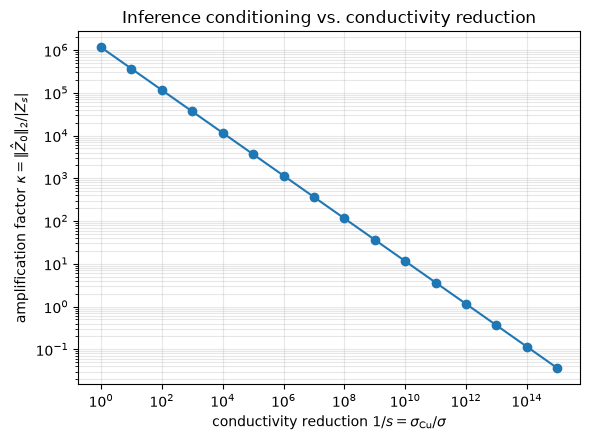

s =    1.0e+00   kappa =    1.157e+06
s =    1.0e-01   kappa =    3.658e+05
s =    1.0e-02   kappa =    1.157e+05
s =    1.0e-03   kappa =    3.658e+04
s =    1.0e-04   kappa =    1.157e+04
s =    1.0e-05   kappa =    3.658e+03
s =    1.0e-06   kappa =    1.157e+03
s =    1.0e-07   kappa =    3.658e+02
s =    1.0e-08   kappa =    1.157e+02
s =    1.0e-09   kappa =    3.658e+01
s =    1.0e-10   kappa =    1.157e+01
s =    1.0e-11   kappa =    3.658e+00
s =    1.0e-12   kappa =    1.157e+00
s =    1.0e-13   kappa =    3.658e-01
s =    1.0e-14   kappa =    1.157e-01
s =    1.0e-15   kappa =    3.658e-02


In [3]:

s_values = np.logspace(0, -15, 16)  # s = 1 (copper) down to 1e-15
kappas = []
for s in s_values:
    sysd = build_system(s)
    kappas.append(kappa_of(sysd))
kappas = np.array(kappas)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(1 / s_values, kappas, 'o-')
ax.set_xlabel(r'conductivity reduction $1/s = \sigma_\mathrm{Cu}/\sigma$')
ax.set_ylabel(r'amplification factor $\kappa = \|\hat{Z}_0\|_2 / |Z_s|$')
ax.set_title('Inference conditioning vs. conductivity reduction')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

for s, k in zip(s_values, kappas):
    print(f"s = {s:>10.1e}   kappa = {k:>12.3e}")


$\kappa$ decreases roughly as $\sqrt{s}$ (since $|Z_\mathrm{s}| \propto 1/\delta \propto \sqrt{\sigma}$
in the good-conductor limit), so many orders of conductivity reduction are needed to bring it down by a
modest factor. The next section checks whether the *achievable* reduction (limited by validity of the
surface-impedance model and by numerical conditioning of $\mathbf Z$ itself) is enough for the ratio-based
inference to become usable.


In [4]:

print(f"cond(Lmat)                 = {np.linalg.cond(Lmat):.3e}")
for s in [1.0, 1e-4, 1e-8, 1e-12, 1e-15]:
    sysd = build_system(s)
    print(f"s = {s:>8.0e}   cond(Zt) = {np.linalg.cond(sysd['Zt']):.3e}   |Zs| = {abs(sysd['Zs']):.3e}   kappa = {kappa_of(sysd):.3e}")


cond(Lmat)                 = 1.500e+00
s =    1e+00   cond(Zt) = 1.155e+04   |Zs| = 1.802e-02   kappa = 1.157e+06
s =    1e-04   cond(Zt) = 5.045e+03   |Zs| = 1.802e+00   kappa = 1.157e+04
s =    1e-08   cond(Zt) = 1.070e+02   |Zs| = 1.802e+02   kappa = 1.157e+02
s =    1e-12   cond(Zt) = 1.858e+00   |Zs| = 1.802e+04   kappa = 1.157e+00
s =    1e-15   cond(Zt) = 1.539e+00   |Zs| = 5.697e+05   kappa = 3.658e-02


## 2. Inference error vs. current perturbation, for each conductivity level

For each conductivity reduction factor $s$, take the *exact* current of the fully filled plate,
$\mathbf I_\mathrm{fp}(s) = \mathbf Z(s)^{-1}\mathbf V$, which by construction must be inferred as
$\varsigma_i \equiv 1$ everywhere. Perturb it by relative noise of magnitude $\|\delta\mathbf I\|/\|\mathbf I\|=\eta$
and measure the worst-case inference error $\max_i|\varsigma_i - 1|$. This isolates the conditioning of the
inference map itself, independent of how close a real dual solver gets to $\mathbf I_\mathrm{fp}$.


In [5]:

s_grid = np.array([1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-15])
eta_grid = np.logspace(-12, -1, 12)
n_trials = 5

err_ratio = np.zeros((len(s_grid), len(eta_grid)))

for i_s, s in enumerate(s_grid):
    sysd = build_system(s)
    Ifp = np.linalg.solve(sysd['Zt'], V)
    for i_eta, eta in enumerate(eta_grid):
        errs = []
        for _ in range(n_trials):
            n = np.random.randn(N) + 1j * np.random.randn(N)
            n *= eta * np.linalg.norm(Ifp) / np.linalg.norm(n)
            dens = infer_whitened(Ifp + n, sysd)
            errs.append(np.max(np.abs(dens - 1)))
        err_ratio[i_s, i_eta] = np.median(errs)

print("done")


done


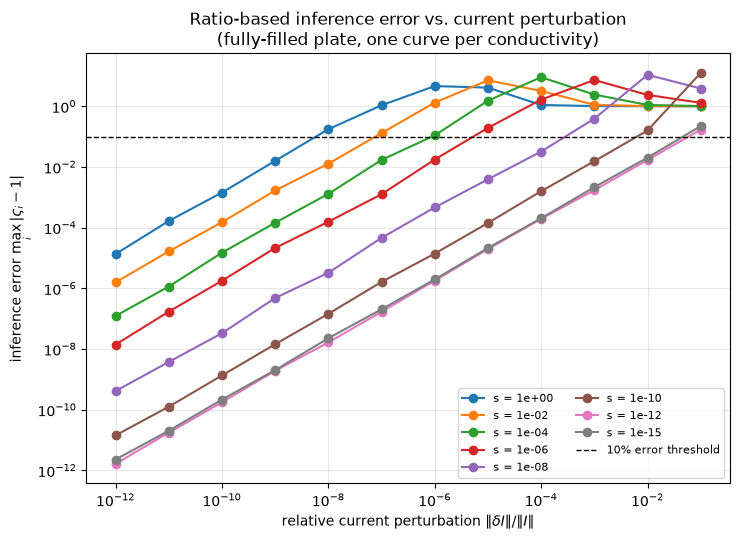

In [6]:

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i_s, s in enumerate(s_grid):
    ax.loglog(eta_grid, err_ratio[i_s], 'o-', label=f's = {s:.0e}')
ax.axhline(0.1, color='k', ls='--', lw=1, label='10% error threshold')
ax.set_xlabel(r'relative current perturbation $\|\delta I\| / \|I\|$')
ax.set_ylabel(r'inference error $\max_i |\varsigma_i - 1|$')
ax.set_title('Ratio-based inference error vs. current perturbation\n(fully-filled plate, one curve per conductivity)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Heatmap: usable region of (perturbation, conductivity) space

The same data as a 2-D map makes the trade-off explicit: reducing the conductivity buys a wider
tolerance on the current error, but the gain is slow (rows shift right roughly as $\sqrt{s}$, matching
the scaling of $\kappa$), while at the same time reducing $s$ pushes the physical surface-impedance model
outside its regime of validity and increases $\mathrm{cond}(\mathbf Z)$, degrading the actual accuracy a
dual solver can reach in the first place.


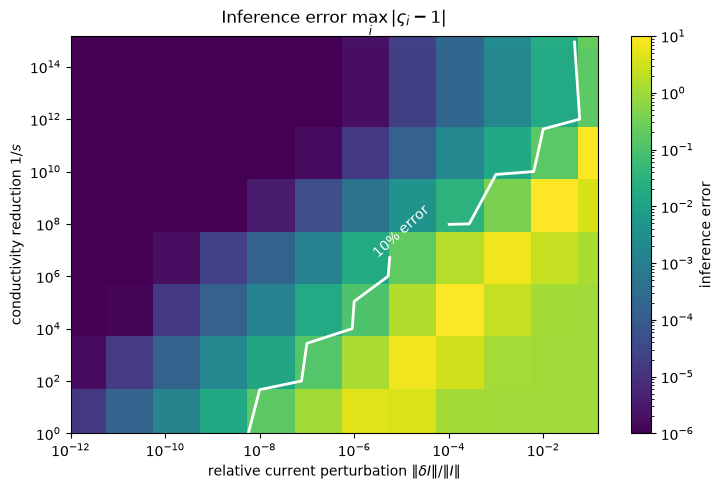

In [7]:

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.pcolormesh(eta_grid, 1 / s_grid, err_ratio, shading='auto',
                    norm=__import__('matplotlib.colors', fromlist=['LogNorm']).LogNorm(vmin=1e-6, vmax=10))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'relative current perturbation $\|\delta I\| / \|I\|$')
ax.set_ylabel(r'conductivity reduction $1/s$')
ax.set_title(r'Inference error $\max_i|\varsigma_i - 1|$')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('inference error')

# overlay 10% contour
CS = ax.contour(eta_grid, 1 / s_grid, err_ratio, levels=[0.1], colors='white', linewidths=2)
ax.clabel(CS, fmt='10%% error')

plt.tight_layout()
plt.show()


## 4. Comparison with the branch-comparison classifier

Instead of asking the ratio to be accurate, the classifier $\beta_i < \alpha_i$
(Eq.~\eqref{eq:classifier} in the companion write-up) only asks which of two normalized magnitudes is
smaller. This is tested on a known, non-trivial binary support (part of the plate removed), embedded by
zeros, so the ground truth is known exactly at every conductivity level and every perturbation.


In [8]:

keep_mask = np.ones(N, dtype=bool)
keep_mask[N // 3 : N // 3 + N // 5] = False  # remove a contiguous block
print(f"Known support: {keep_mask.sum()} / {N} basis functions retained")

frac_ratio = np.zeros((len(s_grid), len(eta_grid)))
frac_class = np.zeros((len(s_grid), len(eta_grid)))

for i_s, s in enumerate(s_grid):
    sysd = build_system(s)
    Zt = sysd['Zt']
    Ib = np.zeros(N, dtype=complex)
    Ib[keep_mask] = np.linalg.solve(Zt[np.ix_(keep_mask, keep_mask)], V[keep_mask])
    for i_eta, eta in enumerate(eta_grid):
        acc_r, acc_c = [], []
        for _ in range(n_trials):
            n = np.random.randn(N) + 1j * np.random.randn(N)
            n *= eta * np.linalg.norm(Ib) / np.linalg.norm(n) if eta > 0 else 0
            I = Ib + n
            dens = np.abs(infer_whitened(I, sysd))
            pred_ratio = np.clip(dens, 0, None) > 0.5
            pred_class = classify(I, sysd)
            acc_r.append(np.mean(pred_ratio == keep_mask))
            acc_c.append(np.mean(pred_class == keep_mask))
        frac_ratio[i_s, i_eta] = np.median(acc_r)
        frac_class[i_s, i_eta] = np.median(acc_c)

print("done")


Known support: 156 / 195 basis functions retained
done


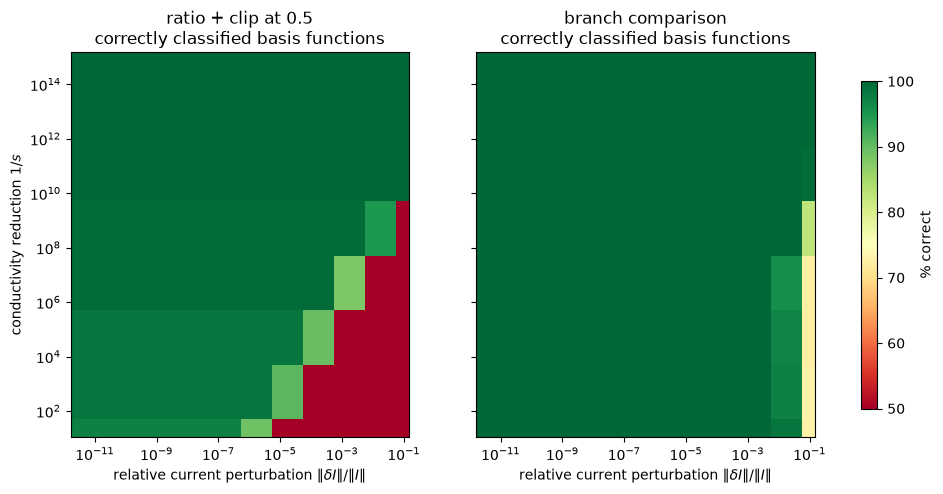

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, data, title in zip(axes, [frac_ratio, frac_class], ['ratio + clip at 0.5', 'branch comparison']):
    im = ax.pcolormesh(eta_grid, 1 / s_grid, data * 100, shading='auto', vmin=50, vmax=100, cmap='RdYlGn')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'relative current perturbation $\|\delta I\| / \|I\|$')
    ax.set_title(f'{title}\ncorrectly classified basis functions')
axes[0].set_ylabel(r'conductivity reduction $1/s$')
fig.colorbar(im, ax=axes, label='% correct', shrink=0.85)
plt.show()


## 5. Summary curves at copper conductivity ($s=1$)

The slice at $s=1$ (actual copper) reproduces the amplification and classification tables reported in
the companion write-up (Section on Numerical Conditioning of the Inference Map), for direct comparison.


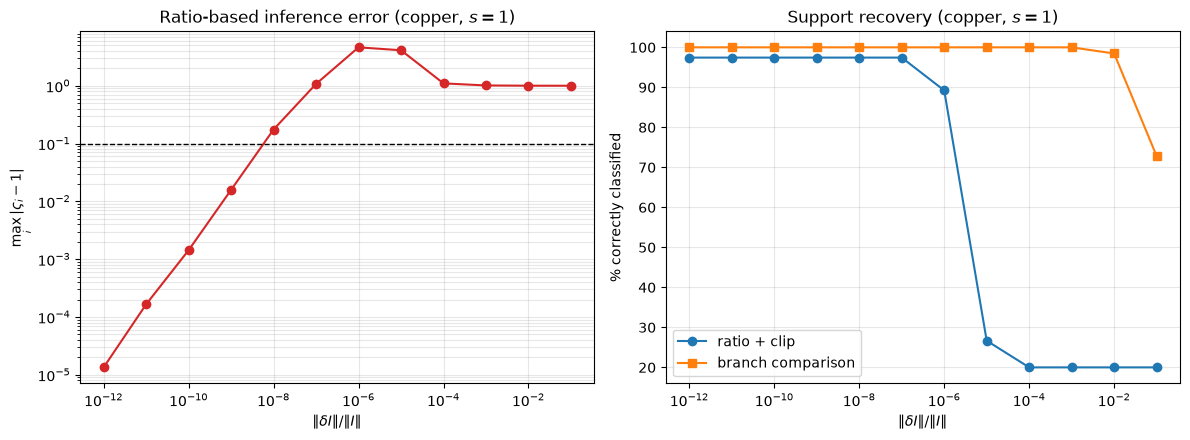

kappa at s=1 (copper): 1.157e+06


In [10]:

i_s1 = np.where(np.isclose(s_grid, 1.0))[0][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].loglog(eta_grid, err_ratio[i_s1], 'o-', color='C3')
axes[0].axhline(0.1, color='k', ls='--', lw=1)
axes[0].set_xlabel(r'$\|\delta I\|/\|I\|$')
axes[0].set_ylabel(r'$\max_i|\varsigma_i - 1|$')
axes[0].set_title('Ratio-based inference error (copper, $s=1$)')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(eta_grid, frac_ratio[i_s1] * 100, 'o-', label='ratio + clip')
axes[1].semilogx(eta_grid, frac_class[i_s1] * 100, 's-', label='branch comparison')
axes[1].set_xlabel(r'$\|\delta I\|/\|I\|$')
axes[1].set_ylabel('% correctly classified')
axes[1].set_title('Support recovery (copper, $s=1$)')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"kappa at s=1 (copper): {kappas[np.where(np.isclose(s_values,1.0))[0][0]] if np.any(np.isclose(s_values,1.0)) else kappa_of(build_system(1.0)):.3e}")


## Conclusions

1. The amplification factor $\kappa = \|\hat{\mathbf Z}_0\|_2/|Z_\mathrm{s}|$ scales as
   $1/\sqrt{s}$, so reducing conductivity by many orders of magnitude buys only a modest reduction
   in $\kappa$, and the ratio-based inference remains unusable at any relative current accuracy an
   iterative dual solver actually achieves ($\gtrsim 10^{-4}$–$10^{-6}$).
2. The heatmap in Section 3 shows the 10%-error boundary shifting slowly to the right as $s$
   decreases — confirming that reducing conductivity trades one problem (non-physical currents in
   the dual solution) for a slower version of the same conditioning problem, not for a cure.
3. The branch-comparison classifier is essentially insensitive to both the conductivity level and
   the perturbation magnitude over the range tested, remaining near 100% correct where the
   ratio-based approach has already collapsed. It should be preferred whenever a binary
   material/vacuum readout is sufficient (Section on Rank-Based Seeding in the companion write-up).
